In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
from PIL import Image
from scipy.linalg import block_diag
import random

# **$k$-means algorithm**

Construct a $150 \times 150$ matrix $\mathbf{A}$ as a $3 \times 3$ block matrix where the blocks are each of size $50 \times 50$, as follows. Each matrix element in a diagonal block has value $p=0.7$ and each matrix element in an off-diagonal black has value $q=0.3$. Now generate a $150 \times 150$ matrix $\mathbf{B}$ of uniformly random numbers in the range $[0,1]$. If $b_{i,j} \geq a_{i,j}$ then replace $a_{i,j}$ with the value 0. This modifies $\mathbf{A}$. The rows of $\mathbf{A}$ have three natural clusters. Namely, the first 50 rows form one natural cluster (corresponding to the first diagonal block), the next 50 rows form another cluster (corresponding to the second diagonal block), and likewise the last 50 rows form the third cluster. One says that random matrix $\mathbf{A}$ comes from the $\textit{stochastic block model}$. Next, generate a random permutation matrix $\mathbf{P} \in \R^{150 \times 150}$ and use it to permute the rows and columns of the matrix $\mathbf{A}$, i.e replace $\mathbf{A}$ by $\mathbf{PAP}^\top$, so that the rows and columns of each cluster are now randomly distributed in $\mathbf{A}$

In [4]:
def generate_PAP(rows, cols):   
    #x[i,j] = ith row and jth column

    #rows by cols, entries all 0.3
    x0 = np.full((rows, cols), 0.3)
    #rows/3 by cols/3, entries all 0.4
    x1 = np.full((rows//3,cols//3), 0.4)
    #rows by cols, only nonzero elements are rows/3 by cols/3 diagonal blocks all equal to 0.4
    x2 = block_diag(x1,x1,x1)
    
    #diagonal blocks have value 0.7, off diagonal blocks have value 0.3
    A = x0+x2
    Af = A.flatten()
    #rows by cols matrix of uniform random numbers from 0 to 1
    B = np.random.uniform(0.0, 1.0, size=(rows, cols))
    Bf = B.flatten()

    #replace entries of A with 0 or 1
    for i in range(len(Af)):
        if (Bf[i] >= Af[i]):
            Af[i] = 1
        else:
            Af[i] = 0
    A = Af.reshape((rows,cols))

    #random rows by cols permutation matrix
    p = np.random.permutation(rows)
    P = np.zeros((len(p), len(p)))
    for i in range(len(p)):
        P[i, p[i]] = 1

    #PAP^T
    PAP = P@A@P.T 
    
    return PAP

PAP = generate_PAP(150,150)

(a) Apply the $k$-means algorithm to the rows of $\mathbf{A}$ with $k=3$. Do you find the correct clusters?

(b) Apply the $k$-means algorithm to $\mathbf{A}$ for $1\leq k\leq10$. Plot the value of the sum of squares to the cluster centers versus $k$. Was 3 the correct value of $k$?

Cluster labels for each row: [2 2 0 2 2 0 1 2 0 2 1 2 0 2 2 2 1 0 2 1 0 0 2 0 0 2 2 2 2 1 2 2 1 1 1 0 1
 1 0 2 1 2 1 0 2 1 1 1 1 0 1 0 2 1 0 2 1 2 1 2 1 0 2 2 1 1 0 2 0 2 1 0 1 0
 2 1 1 1 2 0 0 0 2 2 1 2 0 0 1 1 0 1 0 0 0 1 0 0 0 0 2 1 1 1 1 1 2 2 1 2 2
 2 1 0 1 0 0 2 0 2 1 0 0 2 0 1 0 0 0 2 0 0 2 1 2 2 2 2 1 1 2 1 1 0 0 0 1 0
 1 0]
Number of rows in each cluster: [50, 50, 50]
Objective: 4630.439999999998


Text(0.5, 0, 'Number of k-means clusters')

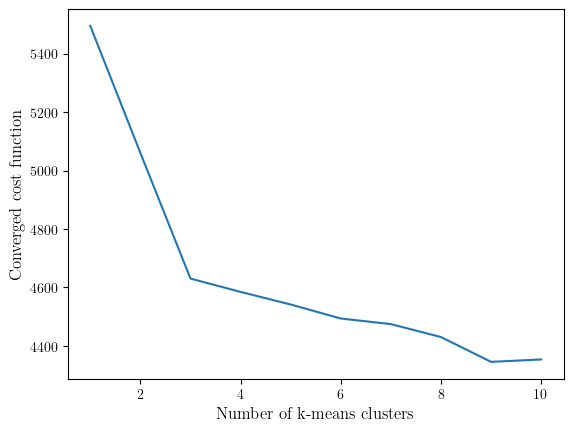

In [5]:
def kmeans_rows(X, n_clusters, n_iter):
    # Initialize centroids randomly
    idx = np.random.choice(X.shape[0], n_clusters, replace=False)
    centroids = X[idx].copy()

    for i in range(n_iter):
        # Compute the kth component of the difference between point x_i and centroid mu_j and store in diff_{ijk}
        diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]

        #Compute squared distances between point x_i and centroid mu_j and store in distances_{i,j}
        distances = np.linalg.norm(diff, axis=2)

        #identify the centroid index that minimizes squared distance between centroids and x_i and store it in labels_{i}
        labels = np.argmin(distances, axis=1)

        # Update centroids
        for k in range(n_clusters):
            if np.any(labels == k):
                centroids[k] = X[labels == k].mean(axis=0)
    
    # Group rows by cluster
    clusters = [X[labels == k] for k in range(n_clusters)]

    objective = 0

    #compute objective function
    for i in range(X.shape[0]):
        centroid = centroids[labels[i]]
        diff = X[i] - centroid
        objective += np.sum(diff**2)
    
    return centroids , labels,  clusters, objective

# Example usage
n_clusters = 3

centroids, labels, clusters, objective = kmeans_rows(PAP, 3, 600)
print("Cluster labels for each row:", labels)
print("Number of rows in each cluster:", [c.shape[0] for c in clusters])
print("Objective:", objective)

k_vals = np.arange(1, 11)
y = np.zeros(len(k_vals))

for idx, k in enumerate(k_vals):
    _, _, _, y[idx] = kmeans_rows(PAP, k, 600)

#plt.figure(dpi=200)
plt.plot(k_vals,y)
plt.ylabel("Converged cost function", fontsize=12)
plt.xlabel("Number of k-means clusters", fontsize=12)

(c) Now let $\Phi \in \R^{10 \times 150}$ be a random i.i.d. spherical Gaussian projection matrix, and apply the $k$-means algorithm to the rows of $\mathbf{A}\Phi^T$ with $k=3$. Do you find the correct clusters?

In [6]:
Phi = np.random.normal(0.0, 1.0/150, size=(10, 150))

PAPPhiT = PAP @ Phi.T

centroids, labels, clusters, objective = kmeans_rows(PAPPhiT, 3, n_iter=600)

print("Cluster labels for each row:", labels)
print("Number of rows in each cluster:", [c.shape[0] for c in clusters])
print("objective:", objective)

Cluster labels for each row: [0 2 2 2 0 2 0 2 2 2 1 0 1 0 2 1 1 2 2 0 0 0 1 0 2 1 1 1 0 1 0 0 0 2 0 2 0
 0 2 1 2 1 0 1 1 1 0 1 1 2 1 2 0 1 0 0 2 2 1 0 0 0 0 1 0 1 2 0 0 2 1 2 1 1
 1 1 0 0 1 2 0 2 1 2 0 2 2 2 1 1 2 0 2 0 2 0 1 2 0 2 1 0 1 2 0 1 0 2 2 2 1
 1 0 2 0 0 0 1 0 0 0 1 2 2 2 0 2 2 2 1 2 0 2 2 2 1 2 0 2 0 1 1 0 1 1 2 0 0
 0 1]
Number of rows in each cluster: [54, 45, 51]
objective: 1.8762433838345132


(d) Finally, let $\mathbf{V}_3\in \R^{d\times k}$ be the orthogonal matrix of the first 3 right singular vectors of $\mathbf{A}$. Apply the $k$-means algorithm to the rows of $\mathbf{AV}_3$ with $k=3$. Do you find the correct clusters?

In [7]:
def powermethod_HW2P7B(M, numvecs, tol, max_iter):
    #matrix x = [x_1|x_2|...|x_numvecs]
    x = np.random.normal(0.0, 1.0, size=(M.shape[0], numvecs))

    for k in range(max_iter):
        E = np.zeros((M.shape[0], numvecs))

        #Gram-schmidt, creates E = [e_1|e_2|...|e_numvecs] where the e_i are an othonormal 
        #basis for the space spanned by the column vectors of x
        for j in range(numvecs):
            e = x[:, j].copy()  # take the j-th column
        
            # Subtract the projections onto previous column vectors
            for i in range(j):
                e -= np.dot(E[:, i], e) * E[:, i]
        
            # Normalize
            norm = np.linalg.norm(e)
            E[:, j] = e / norm

        #new trial value for u_1,u_2,...,u_numvecs
        x_new = M @ (M.T @ E)
        x_new = x_new / np.linalg.norm(x_new, axis=0, keepdims=True)

        #if np.linalg.norm(x_new - x) < tol:
        #   break
        if np.linalg.norm(x_new.T @ x - np.eye(numvecs), ord=2) < tol:
            break

        #left singular vectors
        x = x_new
        U = x

        #right singular vectors
        V = M.T @ U
        V = V / np.linalg.norm(V, axis=0, keepdims=True) 
    return U, V

U, V = powermethod_HW2P7B(PAP, 3, 1e-15, 100)

AV3 = PAP @ V

centroids, labels, clusters, objective = kmeans_rows(AV3, 3, n_iter=600)

print("Cluster labels for each row:", labels)
print("Number of rows in each cluster:", [c.shape[0] for c in clusters])
print("objective:", objective)



Cluster labels for each row: [1 1 0 1 1 0 2 1 0 1 2 1 0 1 1 1 2 0 1 2 0 0 1 0 0 1 1 1 1 2 1 1 2 2 2 0 2
 2 0 1 2 1 2 0 1 2 2 2 2 0 2 0 1 2 0 1 2 1 2 1 2 0 1 1 2 2 0 1 0 1 2 0 2 0
 1 2 2 2 1 0 0 0 1 1 2 1 0 0 2 2 0 2 0 0 0 2 0 0 0 0 1 2 2 2 2 2 1 1 2 1 1
 1 2 0 2 0 0 1 0 1 2 0 0 1 0 2 0 0 0 1 0 0 1 2 1 1 1 1 2 2 1 2 2 0 0 0 2 0
 2 0]
Number of rows in each cluster: [50, 50, 50]
objective: 102.63100847924461
